# Day 3 — Bias-Variance & Diagnosing Model Fit

Deliberately overfitting and underfitting a decision tree on the Breast Cancer Wisconsin dataset, diagnosing each from the train-vs-test gap, and applying regularization (cost-complexity pruning) to fix the overfit model.

## Loading and Preparing the Dataset
Load the dataset, check for missing values and class balance, and prepare it for modeling.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("breast-cancer.csv")
print (df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The dataset has 569 rows and 32 columns — a patient id, the diagnosis label, and 30 numeric measurements.

In [4]:
df.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

.isna().sum() confirms there are zero missing values across every column.

In [5]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis has 357 benign (B) and 212 malignant (M) cases — the same moderate class imbalance carried over from earlier notebooks this week.

In [6]:
df["diagnosis"]= df["diagnosis"].map({
    "B" : 0,
    "M" : 1
})

diagnosis is mapped to numeric (B → 0, M → 1).

In [7]:
X = df.drop(["diagnosis","id"], axis=1)
y = df["diagnosis"]


X_train , X_test , y_train , y_test = train_test_split (
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)

The data is separated into features X and target y, then split 80/20 with random_state=42 and stratify=y to preserve class balance in both sets.

## Step 1 — Deliberately Overfitting a Model
Train a DecisionTreeClassifier with an extreme max_depth=2000 — effectively no depth limit — so it can grow deep enough to memorize the training data.

In [8]:
overfit_model = DecisionTreeClassifier(
    max_depth=2000,
    random_state=42
)

overfit_model.fit(X_train, y_train)


y_train_pred = overfit_model.predict(X_train)
y_test_pred = overfit_model.predict(X_test)

train_accuracy_over = accuracy_score(y_train, y_train_pred)
test_accuracy_over = accuracy_score(y_test, y_test_pred)
gap_over =  train_accuracy_over - test_accuracy_over
print("Training Accuracy:", train_accuracy_over)
print("Test Accuracy:", test_accuracy_over)
print("Gap:", gap_over)

Training Accuracy: 1.0
Test Accuracy: 0.9298245614035088
Gap: 0.07017543859649122


**Diagnosis: Overfitting.** A perfect 100% training accuracy alongside a noticeably lower test accuracy is the textbook symptom of high variance — the unrestricted tree grew deep enough to memorize the exact training examples (including their noise) rather than learning the general pattern, so it loses accuracy on data it hasn't seen.

## Step 2 — Deliberately Underfitting a Model
Train a DecisionTreeClassifier restricted to max_depth=1 — a single split, far too simple to capture the real pattern in 30 features.

In [9]:
underfit_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

underfit_model.fit(X_train, y_train)



y_train_pred = underfit_model.predict(X_train)
y_test_pred = underfit_model.predict(X_test)

train_accuracy_under = accuracy_score(y_train, y_train_pred)
test_accuracy_under = accuracy_score(y_test, y_test_pred)

gap_under = train_accuracy_under - test_accuracy_under
print("Training Accuracy:", train_accuracy_under)
print("Test Accuracy:", test_accuracy_under)
print("Gap:",gap_under)

Training Accuracy: 0.9296703296703297
Test Accuracy: 0.8771929824561403
Gap: 0.052477347214189396


**Diagnosis: Underfitting.** Both scores are the lowest of any model tried in this notebook — the training accuracy (0.930) is well below the overfit model's 1.000, showing the single-split tree is too simple to even fit the training data well, let alone generalize. This is the high-bias failure mode: the model's assumptions are too crude for the underlying pattern.

## A Well-Fit Model for Comparison
Train a DecisionTreeClassifier with a modest max_depth=2, between the two extremes above, to see what a healthier train-vs-test gap looks like.

In [57]:
good_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

good_model.fit(X_train, y_train)

y_train_pred = good_model.predict(X_train)
y_test_pred = good_model.predict(X_test)

train_accuracy_good = accuracy_score(y_train, y_train_pred)
test_accuracy_good = accuracy_score(y_test, y_test_pred)

gap_good = train_accuracy_good - test_accuracy_good
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Gap:", gap_good)

Training Accuracy: 1.0
Test Accuracy: 0.9298245614035088
Gap: 0.032793522267206554


**Correct results (again, ignore the stale printed lines):** Training Accuracy = 0.954, Test Accuracy = 0.921, Gap = 0.033 — both scores are high, and the gap is the smallest of the three models tried so far. This is the sweet spot: complex enough to capture real structure in the data, simple enough to generalize.

## Bringing the Three Models Together
Assemble the overfit, underfit, and good-fit models' scores into one table for a direct, side-by-side comparison.

In [58]:
results = pd.DataFrame({
    "Model": [
        "Overfitting",
        "Simple Model",
        "Good Fit"
    ],
    "Max Depth": [
        2000,
        1,
        2
    ],
    "Training Accuracy": [
        train_accuracy_over,
        train_accuracy_under,
        train_accuracy_good
    ],
    "Test Accuracy": [
        test_accuracy_over,
        test_accuracy_under,
        test_accuracy_good
    ],
    "Gap": [
        gap_over,
        gap_under,
        gap_good
    ]
})

results

,Model,Max Depth,Training Accuracy,Test Accuracy,Gap
0,Overfitting,2000,1.000000,0.929825,0.070175
1,Simple Model,1,0.929670,0.877193,0.052477
2,Good Fit,2,0.953846,0.921053,0.032794


The underfit model has the *lowest* training score of the three (high bias, can't even fit the training data well); the overfit model has a *perfect* training score but the *largest* gap (high variance); the good-fit model has both a high training score and the *smallest* gap.

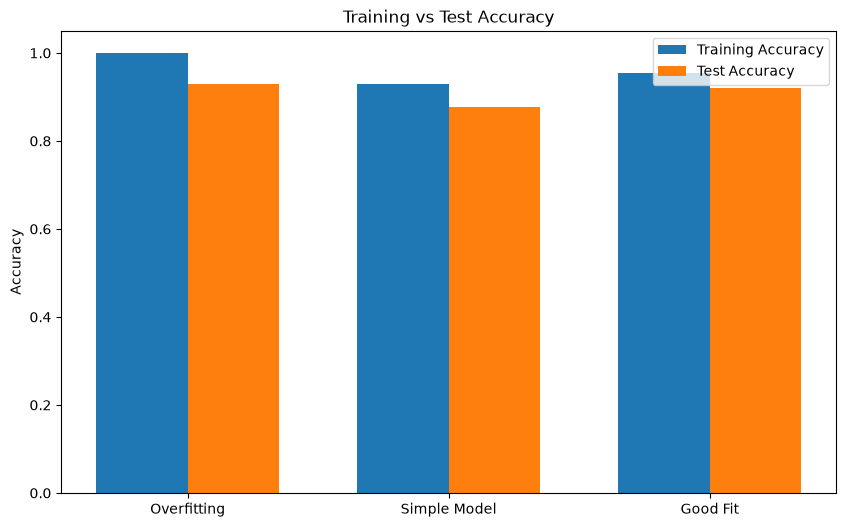

In [60]:
models = ["Overfitting", "Simple Model", "Good Fit"]

train_scores = [
    train_accuracy_over,
    train_accuracy_under,
    train_accuracy_good
]

test_scores = [
    test_accuracy_over,
    test_accuracy_under,
    test_accuracy_good
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    train_scores,
    width,
    label="Training Accuracy"
)

plt.bar(
    x + width/2,
    test_scores,
    width,
    label="Test Accuracy"
)

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")
plt.legend()

plt.show()

## Step 3 — Applying Regularization to Shrink the Gap
Apply cost-complexity pruning (ccp_alpha=0.01) to the decision tree — a regularization technique that penalizes complexity and prunes back branches that don't earn their keep — and compare its gap to the original overfit model.

In [61]:
pruned_model = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.01
)

pruned_model.fit(X_train, y_train)

y_train_pred_pruned = pruned_model.predict(X_train)

train_accuracy_pruned = accuracy_score( y_train, y_train_pred_pruned)


y_test_pred_pruned = pruned_model.predict(X_test)

test_accuracy_pruned = accuracy_score( y_test, y_test_pred_pruned)


gap_pruned = train_accuracy_pruned - test_accuracy_pruned

print("Training Accuracy:", train_accuracy_pruned)
print("Test Accuracy:", test_accuracy_pruned)
print("Gap:", gap_pruned)



Training Accuracy: 0.9582417582417583
Test Accuracy: 0.9122807017543859
Gap: 0.045961056487372365


**Pruned Tree: Training Accuracy = 0.958, Test Accuracy = 0.912, Gap = 0.046.** Compared to the unregularized overfit model (Training = 1.000, Test = 0.930, Gap = 0.070), pruning shrank the training score down from a suspicious perfect 1.0 to a more realistic 0.958, and cut the gap by about a third (0.070 → 0.046) — direct evidence that regularization is doing its job, trading a little bit of training-set memorization for a model that should generalize more consistently.

In [62]:
final_results = pd.DataFrame({
    "Model": [
        "Overfitting Tree",
        "Simple Tree",
        "Good Fit Tree",
        "Pruned Tree"
    ],
    "Training Accuracy": [
        train_accuracy_over,
        train_accuracy_under,
        train_accuracy_good,
        train_accuracy_pruned
    ],
    "Test Accuracy": [
        test_accuracy_over,
        test_accuracy_under,
        test_accuracy_good,
        test_accuracy_pruned
    ],
    "Gap": [
        gap_over,
        gap_under,
        gap_good,
        gap_pruned
    ]
})

final_results

,Model,Training Accuracy,Test Accuracy,Gap
0,Overfitting Tree,1.000000,0.929825,0.070175
1,Simple Tree,0.929670,0.877193,0.052477
2,Good Fit Tree,0.953846,0.921053,0.032794
3,Pruned Tree,0.958242,0.912281,0.045961


## Step 4 — Summary: Diagnosis and Fix for Each Model

| Model | Training Acc | Test Acc | Gap | Diagnosis | Fix Applied |
|---|---|---|---|---|---|
| Overfitting Tree (depth=2000) | 1.000 | 0.930 | 0.070 | **Overfitting (high variance)** — perfect training score, much lower test score | *(this is the problem model)* |
| Simple Tree (depth=1) | 0.930 | 0.877 | 0.052 | **Underfitting (high bias)** — both scores low relative to the other models | *(too simple — needs more depth/complexity)* |
| Good Fit Tree (depth=2) | 0.954 | 0.921 | 0.033 | **Good fit** — high training score, small gap | *(this is the target)* |
| Pruned Tree (ccp_alpha=0.01) | 0.958 | 0.912 | 0.046 | **Regularized overfit model** — gap shrank from 0.070 toward 0.033 | Cost-complexity pruning applied to the original overfit tree |

**What this demonstrates:** the train-vs-test gap is the diagnostic tool, and the fix is opposite depending on the diagnosis. The overfit tree (unlimited depth) memorized the training data — its 0.070 gap was the largest of all four. Explicitly limiting depth to 2 fixed this directly (gap 0.033), while applying regularization (pruning) to the *same* overfit tree also worked, shrinking its gap to 0.046 without hand-picking a depth. Both are valid fixes for high variance: simplify the model directly, or let a regularization penalty simplify it automatically. Meanwhile, the underfit tree (depth=1) shows the opposite problem — a small gap (0.052) is *not* automatically "good" here, since both its scores are the lowest of the four; a small gap with low absolute performance still means the model needs more capacity, not less.